# Retail Profit Analysis (Kaggle Superstore)

Quick analysis of a retail dataset to identify which regions, products, and customer segments are driving profit or loss, and to provide actionable recommendations.


# Data Loading

In this section, we import the necessary Python libraries, create clean table grid and load the dataset into a pandas DataFrame showing the first 5 rows.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/SampleSuperstore.csv", encoding="latin1")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Understanding

Here we explore the structure of the dataset, check data types and identify missing values.

In [24]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Data Formatting

Converts date columns to proper datetime format/

In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


# Data Modelling

Creat useful columns such as Profit Margin which shows if a product is profittable, and inseting time-based columns such as Year and Year-Month columns to easily filter yearly trends or monthly analysis.

In [26]:
df['Profit_Margin'] = df['Profit'] / df['Sales']
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')


# Analysis

This section explores key business questions using grouped summaries and visualizations.



## Profit by Region

In [27]:
region = df.groupby("Region")[["Sales","Profit"]].sum().sort_values("Profit", ascending=False)
region


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


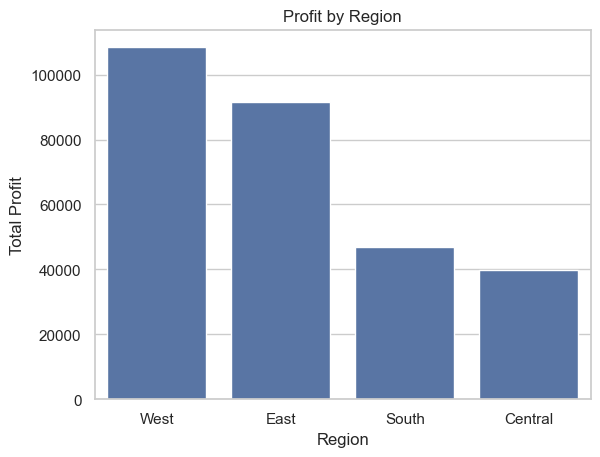

In [28]:
sns.barplot(x=region.index, y=region["Profit"])
plt.title("Profit by Region")
plt.ylabel("Total Profit")
plt.show()



## Profit by Category

In [29]:
cat = df.groupby("Category")[["Sales","Profit"]].sum().sort_values("Profit", ascending=False)
cat


,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


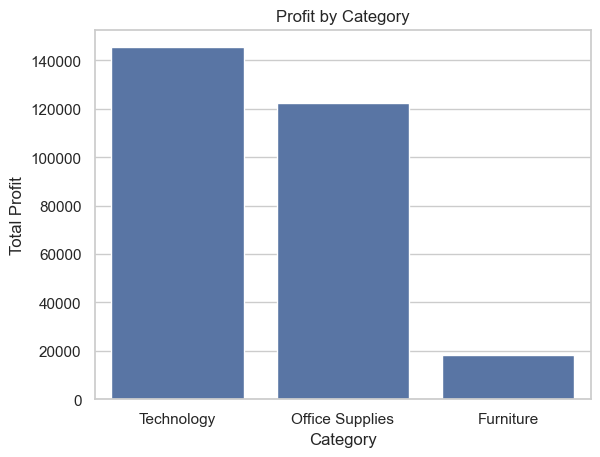

In [30]:
sns.barplot(x=cat.index, y=cat["Profit"])
plt.title("Profit by Category")
plt.ylabel("Total Profit")
plt.show()



## Discount Impact on Profit

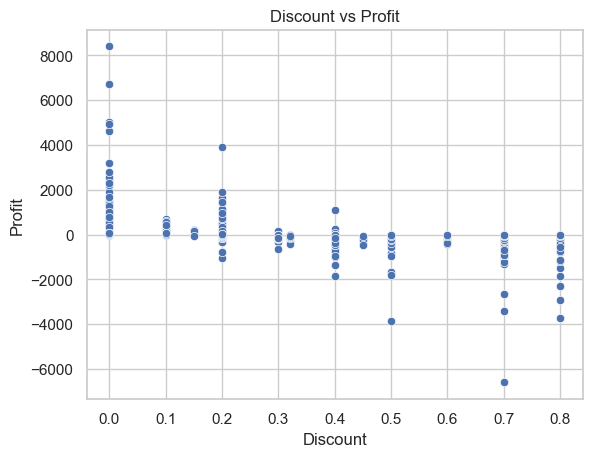

In [31]:
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.show()



## Customer Segment Performance

In [32]:
seg=df.groupby("Segment")[["Sales" , "Profit"]].sum().sort_values("Profit",ascending=False)
seg


,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


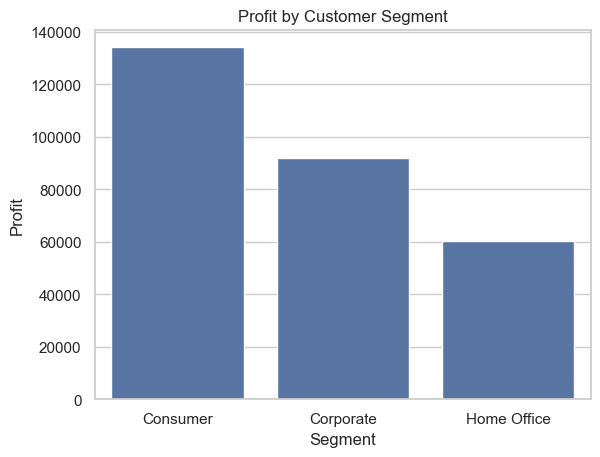

In [33]:
sns.barplot(x=seg.index , y=seg["Profit"])
plt.title("Profit by Customer Segment")
plt.show()

## Key Insights

- The **West region** is the most profitable, while the **Central region** underperforms.
- **Furniture** has relatively lower profit compared to its sales volume.
- **High discounts (above ~30%) are often associated with negative profit.**
- The **Consumer** segment generates higher total profit than other segments.

## Recommendations

1. Reduce or cap discounts in low-margin categories (especially Furniture).
2. Focus sales and marketing efforts on high-profit regions (e.g., West).
3. Review pricing and cost structure for unprofitable sub-categories.
4. Strengthen relationships and targeted campaigns for the Consumer segment.
